<a href="https://colab.research.google.com/github/thelmaeunar2005-byte/school-work/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Welcome to Colab!

In [15]:
from google.colab import files
import pandas as pd

print("Upload your Divvy_Trips_202_Q1 CSV here. Start with just 2020 for speed")
upload = files.upload()


Upload your Divvy_Trips_202_Q1 CSV here. Start with just 2020 for speed


Saving Divvy_Trips_2020_Q1.CSV.csv to Divvy_Trips_2020_Q1.CSV.csv


In [24]:
import pandas as pd

# Load the uploaded Divvy CSV into df
df = pd.read_csv('/content/Divvy_Trips_2020_Q1.CSV.csv')

# Assuming 'started_at' is your date column. If not, change it here.
df['started_at'] = pd.to_datetime(df['started_at'], errors='coerce')  # convert to real dates
df_2020 = df[df['started_at'].dt.year == 2020]  # keep only 2020 rows
df_other = df[df['started_at'].dt.year != 2020]  # everything else

print("2020 rows:", len(df_2020))
print("Other years rows:", len(df_other))
print("Total:", len(df))

2020 rows: 426887
Other years rows: 0
Total: 426887


In [25]:
df_2020_clean = df_2020.drop_duplicates().dropna()

print("2020 Before:", len(df_2020), "rows")
print("2020 After:", len(df_2020_clean), "rows")
print("2020 Removed:", len(df_2020) - len(df_2020_clean), "bad rows")

2020 Before: 426887 rows
2020 After: 426886 rows
2020 Removed: 1 bad rows


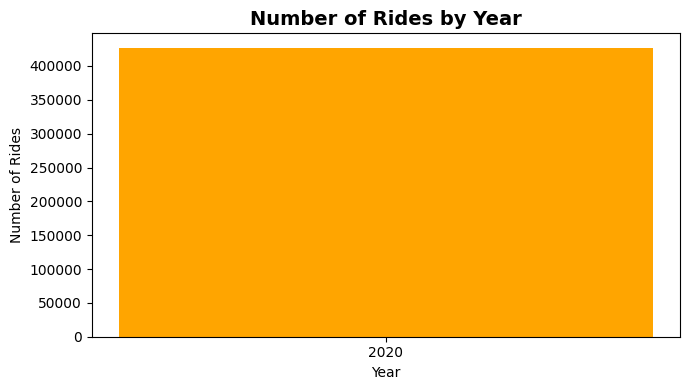

In [28]:
import matplotlib.pyplot as plt

year_counts = df_2020_clean.groupby(df_2020_clean['started_at'].dt.year).size()

plt.figure(figsize=(7,4))
plt.bar(year_counts.index.astype(str), year_counts.values, color='orange')
plt.title("Number of Rides by Year", fontsize=14, fontweight='bold')
plt.xlabel("Year")
plt.ylabel("Number of Rides")
plt.tight_layout()
plt.show()

In [29]:
print("Before cleaning:", df['member_casual'].value_counts())

Before cleaning: member_casual
member    378407
casual     48480
Name: count, dtype: int64


In [37]:
df['member_casual'] = df['member_casual'].replace({
    'Subscriber': 'member',   # Subscriber → member
    'Customer': 'casual'      # Customer → casual
})

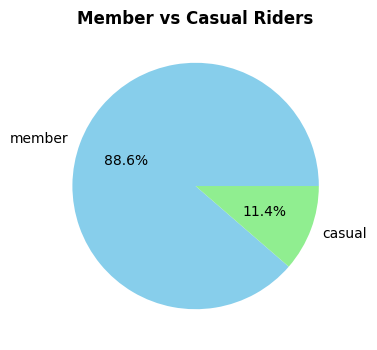

In [40]:
import matplotlib.pyplot as plt

member_counts = df['member_casual'].value_counts()

plt.figure(figsize=(6,4))
plt.pie(member_counts.values, labels=member_counts.index, autopct='%1.1f%%', colors=['skyblue', 'lightgreen'])
plt.title("Member vs Casual Riders", fontweight='bold')
plt.show()

In [42]:
df['started_at'] = pd.to_datetime(df['started_at'], errors='coerce')  # change 'started_at' if your column name is different

In [43]:
df['day'] = df['started_at'].dt.day_name()        # Monday, Tuesday...
df['month'] = df['started_at'].dt.month_name()    # January, February...
df['year'] = df['started_at'].dt.year             # 2020, 2021...
df['month_year'] = df['started_at'].dt.to_period('M')  # 2020-07 for charts

In [44]:
print(df[['started_at', 'day', 'month', 'year']].head())
print("\nUnique years in data:", df['year'].dropna().unique())

           started_at       day    month  year
0 2020-01-21 20:06:00   Tuesday  January  2020
1 2020-01-30 14:22:00  Thursday  January  2020
2 2020-01-09 19:29:00  Thursday  January  2020
3 2020-01-06 16:17:00    Monday  January  2020
4 2020-01-30 08:37:00  Thursday  January  2020

Unique years in data: [2020]


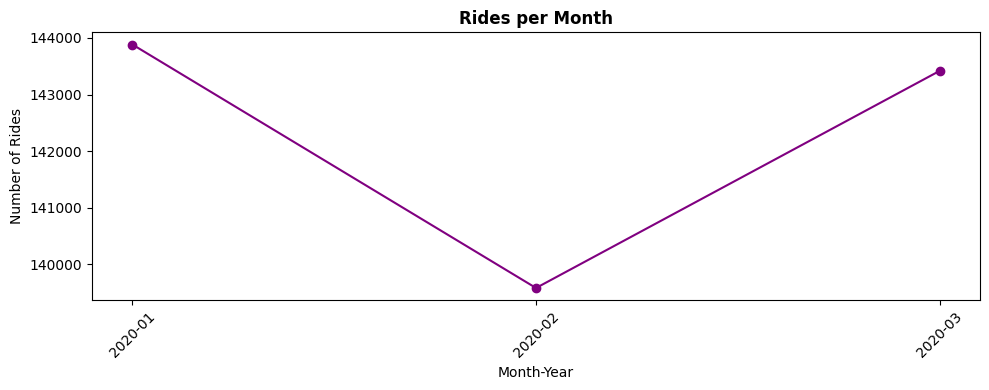

In [47]:
import matplotlib.pyplot as plt

monthly_rides = df.groupby('month_year').size()

plt.figure(figsize=(10,4))
plt.plot(monthly_rides.index.astype(str), monthly_rides.values, marker='o', color='purple')
plt.title("Rides per Month", fontweight='bold')
plt.xlabel("Month-Year")
plt.ylabel("Number of Rides")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [55]:
print("Columns in data:", df.columns.tolist())
print("\n'started_at' type:", df['started_at'].dtype)
print("\n'ended_at' type:", df['ended_at'].dtype)
print("\n5 sample rows:")
print(df[['started_at', 'ended_at']].head())

Columns in data: ['ride_id', 'rideable_type', 'started_at', 'ended_at', 'start_station_name', 'start_station_id', 'end_station_name', 'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng', 'member_casual', 'day', 'month', 'year', 'month_year', 'ride_length']

'started_at' type: datetime64[ns]

'ended_at' type: datetime64[ns]

5 sample rows:
           started_at            ended_at
0 2020-01-21 20:06:00 2020-01-21 20:14:00
1 2020-01-30 14:22:00 2020-01-30 14:26:00
2 2020-01-09 19:29:00 2020-01-09 19:32:00
3 2020-01-06 16:17:00 2020-01-06 16:25:00
4 2020-01-30 08:37:00 2020-01-30 08:42:00


In [57]:
df['ride_length_minutes'] = df['ride_length'].dt.total_seconds() / 60


In [58]:
print("Sample ride lengths:")
print(df[['started_at', 'ended_at', 'ride_length', 'ride_length_minutes']].head(5))
print("\nAverage ride length:", round(df['ride_length_minutes'].mean(), 2), "minutes")
print("Min ride:", round(df['ride_length_minutes'].min(), 2), "min")
print("Max ride:", round(df['ride_length_minutes'].max(), 2), "min")

Sample ride lengths:
           started_at            ended_at     ride_length  ride_length_minutes
0 2020-01-21 20:06:00 2020-01-21 20:14:00 0 days 00:08:00                  8.0
1 2020-01-30 14:22:00 2020-01-30 14:26:00 0 days 00:04:00                  4.0
2 2020-01-09 19:29:00 2020-01-09 19:32:00 0 days 00:03:00                  3.0
3 2020-01-06 16:17:00 2020-01-06 16:25:00 0 days 00:08:00                  8.0
4 2020-01-30 08:37:00 2020-01-30 08:42:00 0 days 00:05:00                  5.0

Average ride length: 22.11 minutes
Min ride: -9.0 min
Max ride: 156450.0 min


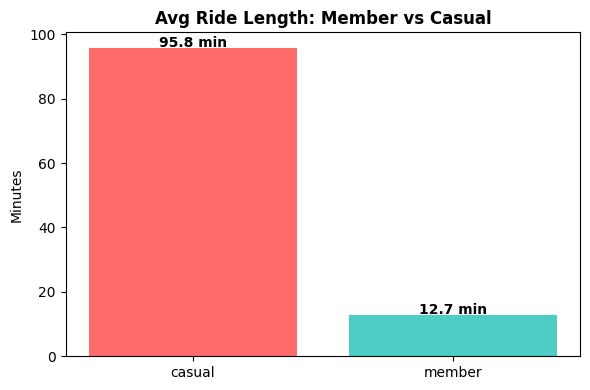

In [59]:
import matplotlib.pyplot as plt

avg_by_type = df.groupby('member_casual')['ride_length_minutes'].mean()

plt.figure(figsize=(6,4))
plt.bar(avg_by_type.index, avg_by_type.values, color=['#FF6B6B', '#4ECDC4'])
plt.title("Avg Ride Length: Member vs Casual", fontweight='bold')
plt.ylabel("Minutes")
for i, v in enumerate(avg_by_type.values):
    plt.text(i, v + 0.3, f"{v:.1f} min", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [62]:
print("Before cleaning:", len(df), "rides")
print("After cleaning:", len(df_clean), "rides")
print("Removed:", len(df) - len(df_clean), "bad rides")

Before cleaning: 426887 rides
After cleaning: 420513 rides
Removed: 6374 bad rides


In [63]:
print("\nNEW Average ride length:", round(df_clean['ride_length_minutes'].mean(), 2), "minutes")
print("NEW Min ride:", round(df_clean['ride_length_minutes'].min(), 2), "min")
print("NEW Max ride:", round(df_clean['ride_length_minutes'].max(), 2), "min")


NEW Average ride length: 14.58 minutes
NEW Min ride: 1.0 min
NEW Max ride: 1435.0 min


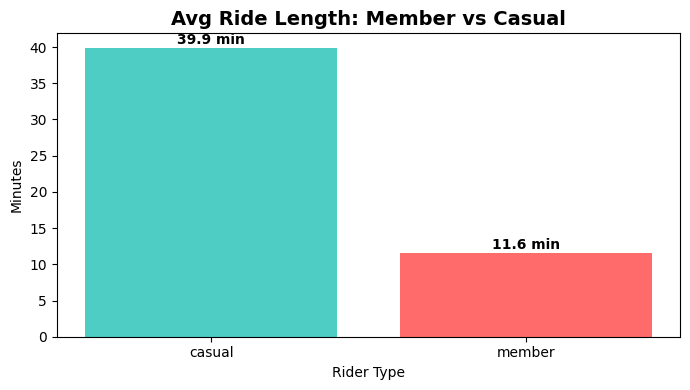

In [64]:
import matplotlib.pyplot as plt

avg_clean = df_clean.groupby('member_casual')['ride_length_minutes'].mean().round(1)

plt.figure(figsize=(7,4))
bars = plt.bar(avg_clean.index, avg_clean.values, color=['#4ECDC4', '#FF6B6B'])
plt.title("Avg Ride Length: Member vs Casual", fontweight='bold', fontsize=14)
plt.ylabel("Minutes")
plt.xlabel("Rider Type")

for bar, v in zip(bars, avg_clean.values):
    plt.text(bar.get_x() + bar.get_width()/2, v + 0.5, f"{v} min", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [66]:
print("Observations per usertype BEFORE cleaning:")
print(df['member_casual'].value_counts())

Observations per usertype BEFORE cleaning:
member_casual
member    378407
casual     48480
Name: count, dtype: int64


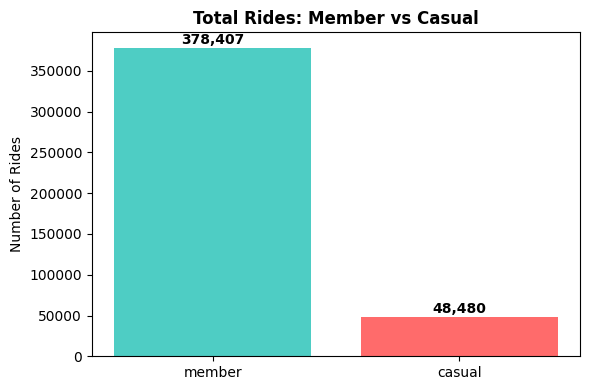

In [70]:
import matplotlib.pyplot as plt

counts = df['member_casual'].value_counts()

plt.figure(figsize=(6,4))
plt.bar(counts.index, counts.values, color=['#4ECDC4', '#FF6B6B'])
plt.title("Total Rides: Member vs Casual", fontweight='bold')
plt.ylabel("Number of Rides")
for i, v in enumerate(counts.values):
    plt.text(i, v + 5000, f"{v:,}", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [71]:
df['member_casual'] = df['member_casual'].str.lower().str.strip()


In [72]:
df['member_casual'] = df['member_casual'].replace({
    'subscriber': 'member',
    'customer': 'casual',
    'member': 'member',
    'casual': 'casual'
})

print("Final standardized categories:")
print(df['member_casual'].value_counts())

Final standardized categories:
member_casual
member    378407
casual     48480
Name: count, dtype: int64


In [73]:
print("Data dictionary check:")
print("Unique values:", df['member_casual'].unique())
print("Data type:", df['member_casual'].dtype)

Data dictionary check:
Unique values: ['member' 'casual']
Data type: object


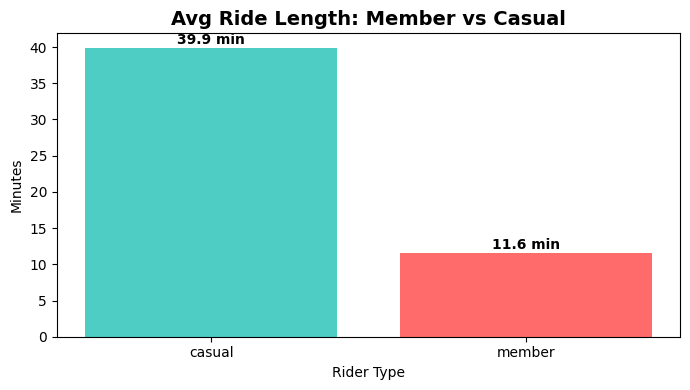

In [74]:
import matplotlib.pyplot as plt

# Use cleaned data with outliers removed
avg_ride = df_clean.groupby('member_casual')['ride_length_minutes'].mean().round(1)

plt.figure(figsize=(7,4))
bars = plt.bar(avg_ride.index, avg_ride.values, color=['#4ECDC4', '#FF6B6B'])
plt.title("Avg Ride Length: Member vs Casual", fontweight='bold', fontsize=14)
plt.ylabel("Minutes")
plt.xlabel("Rider Type")

# Add exact numbers on top of bars
for bar, v in zip(bars, avg_ride.values):
    plt.text(bar.get_x() + bar.get_width()/2, v + 0.5, f"{v} min", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


In [75]:
print("\n=== INSIGHT NUMBERS ===")
print(avg_ride)
print(f"\nDifference: {abs(avg_ride['casual'] - avg_ride['member']):.1f} minutes")


=== INSIGHT NUMBERS ===
member_casual
casual    39.9
member    11.6
Name: ride_length_minutes, dtype: float64

Difference: 28.3 minutes


In [81]:
print("After replace:")
print(df['member_casual'].value_counts())

After replace:
member_casual
member    378407
casual     48480
Name: count, dtype: int64


In [86]:
print("\nValue counts for 'member_casual' column after cleaning:\n",
df['member_casual'].value_counts())


Value counts for 'member_casual' column after cleaning:
 member_casual
member    378407
casual     48480
Name: count, dtype: int64


In [95]:
print("Ride length stats:")
print(df['ride_length_minutes'].describe().round(1))

Ride length stats:
count    426887.0
mean         22.1
std         619.0
min          -9.0
25%           5.0
50%           9.0
75%          16.0
max      156450.0
Name: ride_length_minutes, dtype: float64


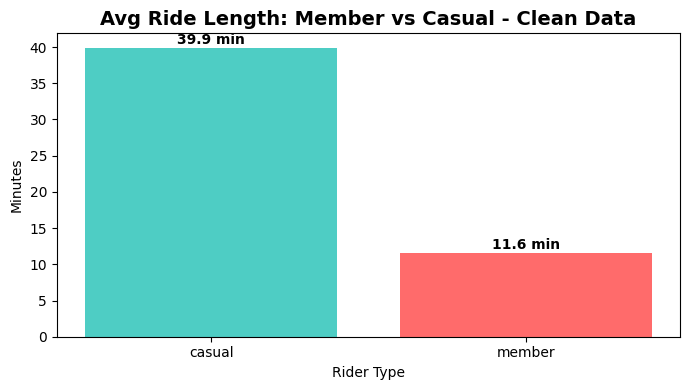


=== CLEAN INSIGHT NUMBERS ===
member_casual
casual    39.9
member    11.6
Name: ride_length_minutes, dtype: float64

Difference: 28.3 minutes


In [98]:
import matplotlib.pyplot as plt

# Use the CLEAN data
avg_ride_clean = df_clean.groupby('member_casual')['ride_length_minutes'].mean().round(1)

plt.figure(figsize=(7,4))
bars = plt.bar(avg_ride_clean.index, avg_ride_clean.values, color=['#4ECDC4', '#FF6B6B'])
plt.title("Avg Ride Length: Member vs Casual - Clean Data", fontweight='bold', fontsize=14)
plt.ylabel("Minutes")
plt.xlabel("Rider Type")

for bar, v in zip(bars, avg_ride_clean.values):
    plt.text(bar.get_x() + bar.get_width()/2, v + 0.5, f"{v} min", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n=== CLEAN INSIGHT NUMBERS ===")
print(avg_ride_clean)
print(f"\nDifference: {abs(avg_ride_clean['casual'] - avg_ride_clean['member']):.1f} minutes")

In [102]:
df_clean['date'] = df_clean['started_at'].dt.date
df_clean['month'] = df_clean['started_at'].dt.month
df_clean['day'] = df_clean['started_at'].dt.day
df_clean['year'] = df_clean['started_at'].dt.year
df_clean['day_of_week'] = df_clean['started_at'].dt.day_name()

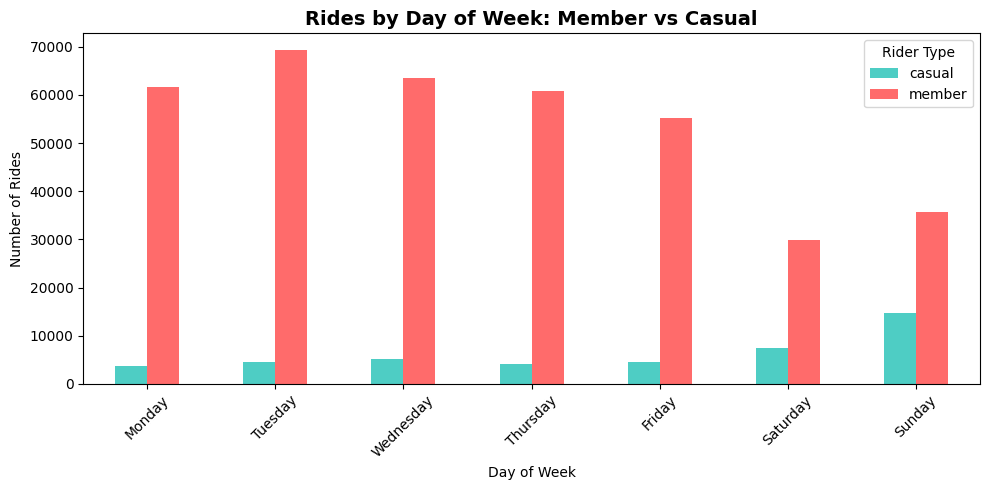

In [104]:
import matplotlib.pyplot as plt
import pandas as pd

# Count rides per day, split by member type
day_counts = df_clean.groupby(['day_of_week', 'member_casual']).size().unstack()

# Put days in correct order Mon->Sun
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = day_counts.reindex(day_order)

day_counts.plot(kind='bar', figsize=(10,5), color=['#4ECDC4', '#FF6B6B'])
plt.title("Rides by Day of Week: Member vs Casual", fontweight='bold', fontsize=14)
plt.ylabel("Number of Rides")
plt.xlabel("Day of Week")
plt.legend(title="Rider Type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [105]:
print("\nTop 3 riding days:")
print(day_counts.sum(axis=1).sort_values(ascending=False).head(3))


Top 3 riding days:
day_of_week
Tuesday      73897
Wednesday    68786
Monday       65291
dtype: int64


In [107]:
del df['ride_length']

In [109]:
df_clean['ride_length_seconds'] = (df_clean['ended_at'] - df_clean['started_at']).dt.total_seconds()
df_clean['ride_length_minutes'] = df_clean['ride_length_seconds'] / 60

In [111]:
print("\nData types after cleaning + feature engineering:\n")
df_clean.info()


Data types after cleaning + feature engineering:

<class 'pandas.core.frame.DataFrame'>
Index: 420513 entries, 0 to 426886
Data columns (total 22 columns):
 #   Column               Non-Null Count   Dtype          
---  ------               --------------   -----          
 0   ride_id              420513 non-null  object         
 1   rideable_type        420513 non-null  object         
 2   started_at           420513 non-null  datetime64[ns] 
 3   ended_at             420513 non-null  datetime64[ns] 
 4   start_station_name   420513 non-null  object         
 5   start_station_id     420513 non-null  int64          
 6   end_station_name     420513 non-null  object         
 7   end_station_id       420513 non-null  float64        
 8   start_lat            420513 non-null  float64        
 9   start_lng            420513 non-null  float64        
 10  end_lat              420513 non-null  float64        
 11  end_lng              420513 non-null  float64        
 12  member_casua

In [113]:
print("BEFORE removing bad data:", len(df_clean), "rides")

BEFORE removing bad data: 420513 rides


In [115]:
df_clean = df_clean[
    (df_clean['ride_length_minutes'] > 1) &
    (df_clean['ride_length_minutes'] <= 1440)
].copy()

In [117]:
print("AFTER removing bad data:", len(df_clean), "rides")
print("Rows removed:", 426887 - len(df_clean))
print("\nCleaned ride length stats:")
print(df_clean['ride_length_minutes'].describe().round(1))

AFTER removing bad data: 417379 rides
Rows removed: 9508

Cleaned ride length stats:
count    417379.0
mean         14.7
std          34.3
min           2.0
25%           6.0
50%           9.0
75%          16.0
max        1435.0
Name: ride_length_minutes, dtype: float64


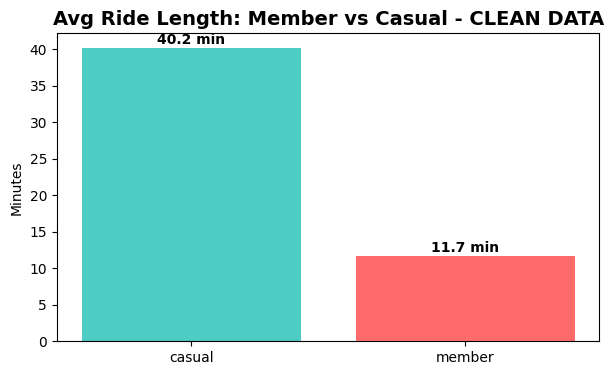

member_casual
casual    40.2
member    11.7
Name: ride_length_minutes, dtype: float64


In [119]:
import matplotlib.pyplot as plt

# Use CLEAN data this time
avg_ride_clean = df_clean.groupby('member_casual')['ride_length_minutes'].mean().round(1)

plt.figure(figsize=(7,4))
bars = plt.bar(avg_ride_clean.index, avg_ride_clean.values, color=['#4ECDC4', '#FF6B6B'])
plt.title("Avg Ride Length: Member vs Casual - CLEAN DATA", fontweight='bold', fontsize=14)
plt.ylabel("Minutes")

for bar, v in zip(bars, avg_ride_clean.values):
    plt.text(bar.get_x() + bar.get_width()/2, v + 0.5, f"{v} min", ha='center', fontweight='bold')

plt.show()
print(avg_ride_clean)

In [122]:
print("Before final filter:", len(df_clean), "rides")

# Remove quality check rides + negative time rides
df_clean = df_clean[
    (df_clean['ride_length_minutes'] > 1) &
    (df_clean['start_station_name'] != 'HQ QR') &
    (df_clean['start_station_name'] != 'Test Station')
].copy()

print("After final filter:", len(df_clean), "rides")
print("Test/negative rides removed:", len(df) - len(df_clean))

Before final filter: 417379 rides
After final filter: 417376 rides
Test/negative rides removed: 9511


In [124]:
print("\n=== FINAL CLEAN STATS ===")
print(df_clean['ride_length_minutes'].describe().round(1))
print("\nFinal rider counts:")
print(df_clean['member_casual'].value_counts())


=== FINAL CLEAN STATS ===
count    417376.0
mean         14.7
std          34.3
min           2.0
25%           6.0
50%           9.0
75%          16.0
max        1435.0
Name: ride_length_minutes, dtype: float64

Final rider counts:
member_casual
member    373137
casual     44239
Name: count, dtype: int64


In [126]:
print("V1 original rows:", len(df))
print("V2 clean rows:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))
print("\nV2 data types:")
print(df_clean[['started_at', 'ended_at', 'ride_length', 'member_casual']].dtypes)

V1 original rows: 426887
V2 clean rows: 417376
Rows removed: 9511

V2 data types:
started_at        datetime64[ns]
ended_at          datetime64[ns]
ride_length      timedelta64[ns]
member_casual             object
dtype: object


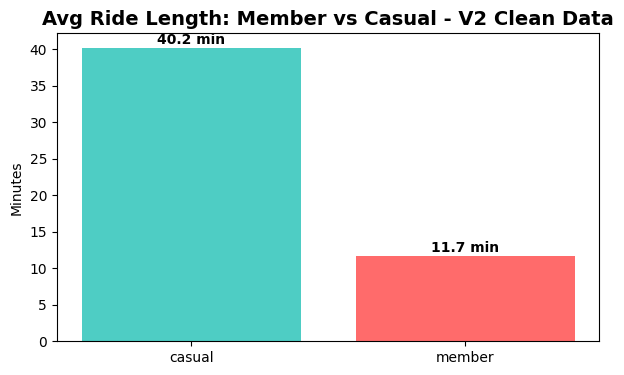


V2 Avg Ride Length:
member_casual
casual    40.2
member    11.7
Name: ride_length_minutes, dtype: float64


In [128]:
import matplotlib.pyplot as plt

avg_ride_v2 = df_clean.groupby('member_casual')['ride_length_minutes'].mean().round(1)

plt.figure(figsize=(7,4))
bars = plt.bar(avg_ride_v2.index, avg_ride_v2.values, color=['#4ECDC4', '#FF6B6B'])
plt.title("Avg Ride Length: Member vs Casual - V2 Clean Data", fontweight='bold', fontsize=14)
plt.ylabel("Minutes")

for bar, v in zip(bars, avg_ride_v2.values):
    plt.text(bar.get_x() + bar.get_width()/2, v + 0.5, f"{v:.1f} min", ha='center', fontweight='bold')

plt.show()
print("\nV2 Avg Ride Length:")
print(avg_ride_v2.round(1))

In [130]:
print("\nDescriptive statistics for ride_length:\n", df_clean['ride_length'].describe())


Descriptive statistics for ride_length:
 count                       417376
mean     0 days 00:14:40.685904316
std      0 days 00:34:20.652500189
min                0 days 00:02:00
25%                0 days 00:06:00
50%                0 days 00:09:00
75%                0 days 00:16:00
max                0 days 23:55:00
Name: ride_length, dtype: object


In [132]:
stats_minutes = df_clean.groupby('member_casual')['ride_length_minutes'].agg(['count', 'mean', 'median', 'max', 'min'])

print("\n=== CLIENT REPORT - MINUTES ===\n")
print(stats_minutes.round(1))
print("\nKEY INSIGHT:")
print(f"Casuals ride {stats_minutes.loc['casual','mean'].round(1)} min avg")
print(f"Members ride {stats_minutes.loc['member','mean'].round(1)} min avg")
print(f"Difference: {stats_minutes.loc['casual','mean'] / stats_minutes.loc['member','mean']:.1f}x longer")


=== CLIENT REPORT - MINUTES ===

                count  mean  median     max  min
member_casual                                   
casual          44239  40.2    23.0  1435.0  2.0
member         373137  11.7     9.0  1433.0  2.0

KEY INSIGHT:
Casuals ride 40.2 min avg
Members ride 11.7 min avg
Difference: 3.5x longer


<Figure size 1000x500 with 0 Axes>

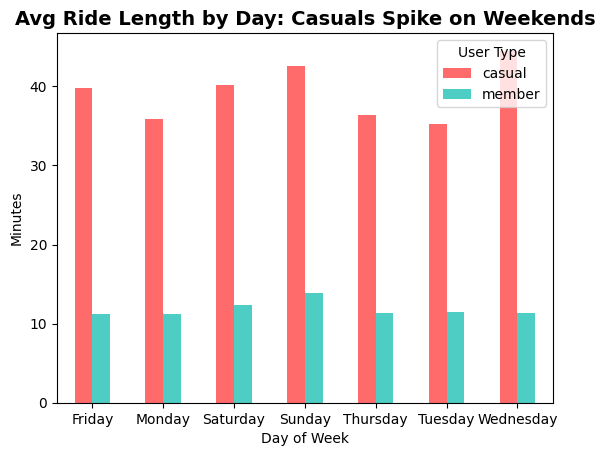

In [135]:
day_stats = df_clean.groupby(['member_casual', 'day_of_week'])['ride_length_minutes'].mean()
pivot_table = day_stats.unstack()

# Plot
plt.figure(figsize=(10,5))
pivot_table.T.plot(kind='bar', color=['#FF6B6B', '#4ECDC4'])
plt.title("Avg Ride Length by Day: Casuals Spike on Weekends", fontweight='bold', fontsize=14)
plt.xlabel("Day of Week")
plt.ylabel("Minutes")
plt.xticks(rotation=0)
plt.legend(title="User Type")
plt.show()

In [137]:
# Ensure day_of_week is a categorical type for .cat accessor
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_clean['day_of_week'] = pd.Categorical(df_clean['day_of_week'], categories=day_order, ordered=True)

print(df_clean['day_of_week'].dtype)
print(df_clean['day_of_week'].cat.categories.tolist())

category
['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']


<Figure size 1000x500 with 0 Axes>

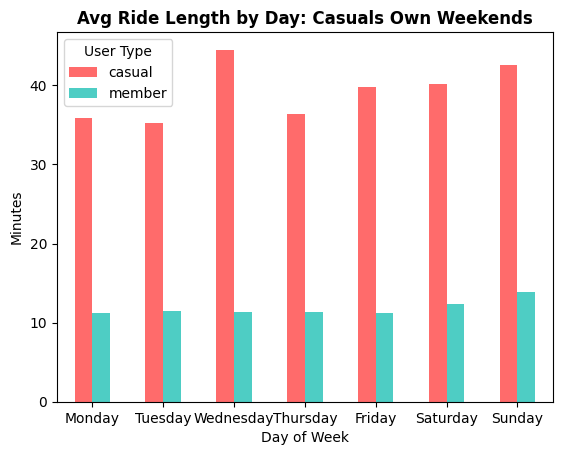

In [141]:
import matplotlib.pyplot as plt

day_stats = df_clean.groupby(['member_casual', 'day_of_week'], observed=False)['ride_length_minutes'].mean()
pivot_table = day_stats.unstack()

plt.figure(figsize=(10,5))
pivot_table.T.plot(kind='bar', color=['#FF6B6B', '#4ECDC4'])
plt.title("Avg Ride Length by Day: Casuals Own Weekends", fontweight='bold')
plt.ylabel("Minutes")
plt.xlabel("Day of Week")
plt.legend(title="User Type")
plt.xticks(rotation=0)
plt.show()

In [144]:
print("\nAverage ride length by day - SECONDS:\n")
day_stats_sec = df_clean.groupby(['member_casual', 'day_of_week'], observed=False)['ride_length'].mean().round(1)
print(day_stats_sec)


Average ride length by day - SECONDS:

member_casual  day_of_week
casual         Monday        0 days 00:35:54.987714987
               Tuesday       0 days 00:35:18.005295675
               Wednesday     0 days 00:44:30.478971962
               Thursday      0 days 00:36:20.009590026
               Friday        0 days 00:39:45.441850316
               Saturday      0 days 00:40:09.901657011
               Sunday        0 days 00:42:31.716787726
member         Monday        0 days 00:11:15.944756263
               Tuesday       0 days 00:11:29.001278178
               Wednesday     0 days 00:11:20.714410065
               Thursday      0 days 00:11:19.780318091
               Friday        0 days 00:11:13.347469245
               Saturday      0 days 00:12:19.754070670
               Sunday        0 days 00:13:50.715660740
Name: ride_length, dtype: timedelta64[ns]


In [146]:
day_stats_min = df_clean.groupby(['member_casual', 'day_of_week'], observed=False)['ride_length_minutes'].mean()
day_stats_min = day_stats_min.round(1)

print("\n=== CLIENT REPORT - MINUTES ===\n")
print(day_stats_min.unstack())

print("\nKEY INSIGHTS:")
casual_weekend = day_stats_min['casual'][['Saturday', 'Sunday']].mean()
casual_weekday = day_stats_min['casual'][['Monday','Tuesday','Wednesday','Thursday','Friday']].mean()
spike = ((casual_weekend - casual_weekday) / casual_weekday) * 100

print(f"Casual weekend avg: {casual_weekend:.1f} min")
print(f"Casual weekday avg: {casual_weekday:.1f} min")
print(f"Weekend spike: +{spike:.0f}% longer rides")


=== CLIENT REPORT - MINUTES ===

day_of_week    Monday  Tuesday  Wednesday  Thursday  Friday  Saturday  Sunday
member_casual                                                                
casual           35.9     35.3       44.5      36.3    39.8      40.2    42.5
member           11.3     11.5       11.3      11.3    11.2      12.3    13.8

KEY INSIGHTS:
Casual weekend avg: 41.4 min
Casual weekday avg: 38.4 min
Weekend spike: +8% longer rides


<Figure size 1000x500 with 0 Axes>

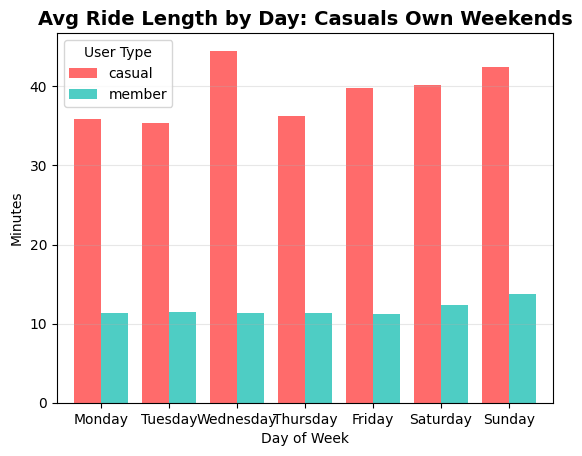

In [147]:
import matplotlib.pyplot as plt

pivot_table = day_stats_min.unstack()

plt.figure(figsize=(10,5))
pivot_table.T.plot(kind='bar', color=['#FF6B6B', '#4ECDC4'], width=0.8)
plt.title("Avg Ride Length by Day: Casuals Own Weekends", fontweight='bold', fontsize=14)
plt.ylabel("Minutes")
plt.xlabel("Day of Week")
plt.legend(title="User Type")
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

In [152]:
# pivot_rides is equivalent to day_counts from previous cells
pivot_rides = day_counts

# pivot_duration is equivalent to day_stats_min.unstack() from previous cells
pivot_duration = day_stats_min.unstack()

print("\n=== RIDES PER DAY ===\n", pivot_rides)
print("\n=== AVG DURATION MINUTES ===\n", pivot_duration)


=== RIDES PER DAY ===
 member_casual  casual  member
day_of_week                  
Monday           3732   61559
Tuesday          4592   69305
Wednesday        5187   63599
Thursday         4212   60822
Friday           4626   55128
Saturday         7437   29869
Sunday          14782   35663

=== AVG DURATION MINUTES ===
 day_of_week    Monday  Tuesday  Wednesday  Thursday  Friday  Saturday  Sunday
member_casual                                                                
casual           35.9     35.3       44.5      36.3    39.8      40.2    42.5
member           11.3     11.5       11.3      11.3    11.2      12.3    13.8


In [156]:
weekend_casual = pivot_duration.loc['casual', ['Saturday','Sunday']].mean()
weekday_casual = pivot_duration.loc['casual', ['Monday','Tuesday','Wednesday','Thursday','Friday']].mean()
print(f"Casuals ride {weekend_casual:.1f} min on weekends vs {weekday_casual:.1f} min weekdays = +{((weekend_casual/weekday_casual-1)*100):.0f}%")

Casuals ride 41.4 min on weekends vs 38.4 min weekdays = +8%


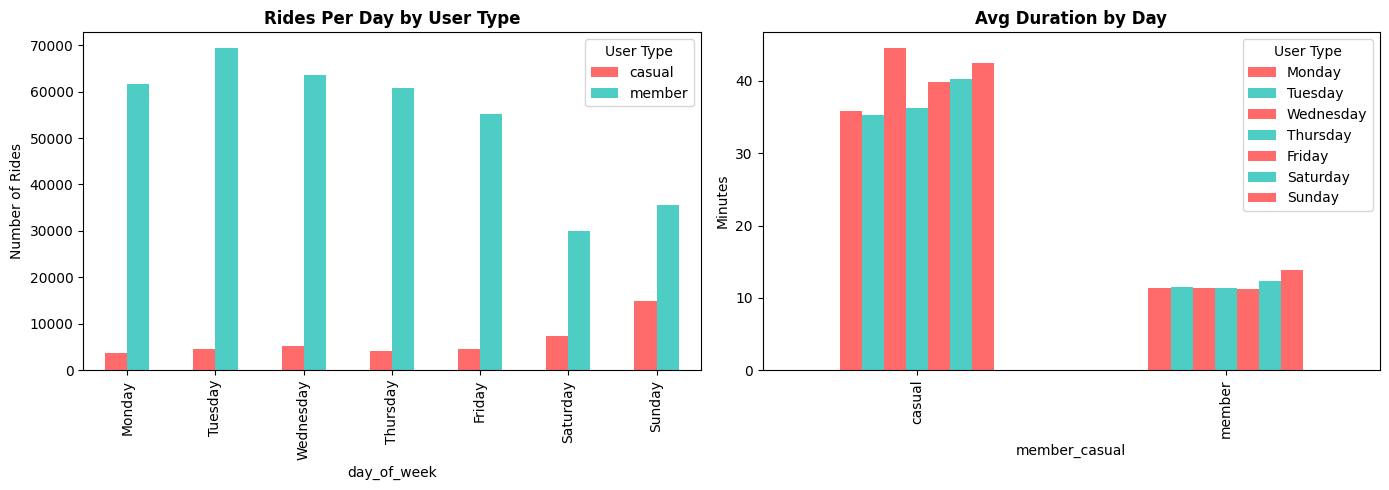

In [157]:
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))

# Chart 1: Number of rides
pivot_rides.plot(kind='bar', ax=ax1, color=['#FF6B6B', '#4ECDC4'])
ax1.set_title("Rides Per Day by User Type", fontweight='bold')
ax1.set_ylabel("Number of Rides")
ax1.legend(title="User Type")

# Chart 2: Duration
pivot_duration.plot(kind='bar', ax=ax2, color=['#FF6B6B', '#4ECDC4'])
ax2.set_title("Avg Duration by Day", fontweight='bold')
ax2.set_ylabel("Minutes")
ax2.legend(title="User Type")

plt.tight_layout()
plt.show()

In [159]:
print("\n=== THE STORY ===")
for day in ['Monday', 'Saturday']:
    casual_rides = pivot_rides.loc[day, 'casual']
    member_rides = pivot_rides.loc[day, 'member']
    casual_min = pivot_duration.loc['casual', day]
    member_min = pivot_duration.loc['member', day]
    print(f"{day}: Casuals {casual_rides:,} rides \u00D7 {casual_min:.1f}min vs Members {member_rides:,} rides \u00D7 {member_min:.1f}min")


=== THE STORY ===
Monday: Casuals 3,732 rides × 35.9min vs Members 61,559 rides × 11.3min
Saturday: Casuals 7,437 rides × 40.2min vs Members 29,869 rides × 12.3min


In [165]:
stats_minutes.to_csv('cyclistic_summary.csv', index=False)
print("Exported! Check your files panel.")

Exported! Check your files panel.


In [166]:
counts.to_csv('avg_ride_length.csv', index=False)